# Machine Learning Part

In [187]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare Clean Data

In [188]:
almond = pd.read_csv("Datasets/almond_clean.csv")

almond_onehot = almond.copy()

almond.head()

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,321.807244,227.940628,127.759132,22619.0,643.813269,0.403849,0.973384,1.458265,1.923085,0.846328,0.681193,23237.5,MAMRA
1,321.807244,234.188126,128.199509,23038.0,680.984841,0.403849,0.957304,1.601844,1.923085,0.846328,0.656353,24065.5,MAMRA
2,321.807244,229.418610,125.796547,22386.5,646.943212,0.403849,0.967270,1.487772,1.923085,0.846328,0.683620,23144.0,MAMRA
3,321.807244,232.763153,125.918808,22578.5,661.227483,0.403849,0.965512,1.540979,1.923085,0.846328,0.685360,23385.0,MAMRA
4,321.807244,230.150742,107.253448,19068.0,624.842706,0.403849,0.951450,1.629395,1.923085,0.846328,0.714800,20041.0,MAMRA


## Encoding
Side note: Since we are dealing with almond classification, we don't need to onehot_encode the 'type' column. We don't need encoding at all.

In [189]:
#Use One-Hot Encoding to convert categorical variables into numerical format
almond_onehot = pd.get_dummies(almond_onehot, columns=['type'], drop_first=False)

In [190]:
almond_onehot

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type_MAMRA,type_REGULAR,type_SANORA
0,321.807244,227.940628,127.759132,22619.0,643.813269,0.403849,0.973384,1.458265,1.923085,0.846328,0.681193,23237.5,True,False,False
1,321.807244,234.188126,128.199509,23038.0,680.984841,0.403849,0.957304,1.601844,1.923085,0.846328,0.656353,24065.5,True,False,False
2,321.807244,229.418610,125.796547,22386.5,646.943212,0.403849,0.967270,1.487772,1.923085,0.846328,0.683620,23144.0,True,False,False
3,321.807244,232.763153,125.918808,22578.5,661.227483,0.403849,0.965512,1.540979,1.923085,0.846328,0.685360,23385.0,True,False,False
4,321.807244,230.150742,107.253448,19068.0,624.842706,0.403849,0.951450,1.629395,1.923085,0.846328,0.714800,20041.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,283.245347,192.709366,122.356506,18471.5,653.345233,0.500045,0.931000,1.838965,1.634305,0.789078,0.725739,19840.5,False,False,True
2799,283.245347,186.254745,118.708961,17213.5,581.688379,0.500045,0.952706,1.564234,1.634305,0.789078,0.714016,18068.0,False,False,True
2800,283.245347,186.196182,119.147224,17510.5,608.315795,0.500045,0.948821,1.681705,1.634305,0.789078,0.718999,18455.0,False,False,True
2801,283.245347,188.660828,120.634438,17941.0,630.759446,0.500045,0.944810,1.764701,1.634305,0.789078,0.738191,18989.0,False,False,True


## Scaling

### Using Standard Scaling for logistic regression

In [191]:
almond_standard_scaled = almond.copy()

#Standardize the numerical features
scaler = StandardScaler()
numerical_features = ['length', 'width', 'thickness', 'area', 'perimeter', 'aspect_ratio', 'convex_hull']
almond_standard_scaled[numerical_features] = scaler.fit_transform(almond_standard_scaled[numerical_features])

In [192]:
almond_standard_scaled

,length,width,thickness,area,perimeter,roundness,solidity,compactness,aspect_ratio,eccentricity,extent,convex_hull,type
0,0.586902,2.296827,1.166217,-0.282445,-0.433887,0.403849,0.973384,1.458265,1.109581,0.846328,0.681193,-0.313226,MAMRA
1,0.586902,2.548901,1.194369,-0.252039,-0.272686,0.403849,0.957304,1.601844,1.109581,0.846328,0.656353,-0.255059,MAMRA
2,0.586902,2.356461,1.040754,-0.299317,-0.420314,0.403849,0.967270,1.487772,1.109581,0.846328,0.683620,-0.319795,MAMRA
3,0.586902,2.491406,1.048569,-0.285384,-0.358367,0.403849,0.965512,1.540979,1.109581,0.846328,0.685360,-0.302865,MAMRA
4,0.586902,2.386001,-0.144665,-0.540135,-0.516157,0.403849,0.951450,1.629395,1.109581,0.846328,0.714800,-0.537782,MAMRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2798,-0.130134,0.875315,0.820840,-0.583422,-0.392550,0.500045,0.931000,1.838965,-0.704147,0.789078,0.725739,-0.551867,SANORA
2799,-0.130134,0.614884,0.587660,-0.674713,-0.703303,0.500045,0.952706,1.564234,-0.704147,0.789078,0.714016,-0.676386,SANORA
2800,-0.130134,0.612521,0.615677,-0.653160,-0.587829,0.500045,0.948821,1.681705,-0.704147,0.789078,0.718999,-0.649199,SANORA
2801,-0.130134,0.711964,0.710752,-0.621920,-0.490498,0.500045,0.944810,1.764701,-0.704147,0.789078,0.738191,-0.611685,SANORA


# Machine Learn Using Logistic Regression

## Predicting Almond Type

In [193]:
# Copy again
learning_data = almond_standard_scaled.copy()

In [194]:
# X = learning features
X = learning_data[['length', 'width', 'thickness', 'area', 'perimeter', 'roundness', 'solidity', 'compactness', 'aspect_ratio', 'eccentricity', 'extent', 'convex_hull']]

# y = target variable
y = learning_data[['type']]

print("Learning Features:")
print(X)
print("Target Variable:")
print(y)

Learning Features:
        length     width  thickness      area  perimeter  roundness  solidity  \
0     0.586902  2.296827   1.166217 -0.282445  -0.433887   0.403849  0.973384   
1     0.586902  2.548901   1.194369 -0.252039  -0.272686   0.403849  0.957304   
2     0.586902  2.356461   1.040754 -0.299317  -0.420314   0.403849  0.967270   
3     0.586902  2.491406   1.048569 -0.285384  -0.358367   0.403849  0.965512   
4     0.586902  2.386001  -0.144665 -0.540135  -0.516157   0.403849  0.951450   
...        ...       ...        ...       ...        ...        ...       ...   
2798 -0.130134  0.875315   0.820840 -0.583422  -0.392550   0.500045  0.931000   
2799 -0.130134  0.614884   0.587660 -0.674713  -0.703303   0.500045  0.952706   
2800 -0.130134  0.612521   0.615677 -0.653160  -0.587829   0.500045  0.948821   
2801 -0.130134  0.711964   0.710752 -0.621920  -0.490498   0.500045  0.944810   
2802 -0.388382  0.202079   0.374319  0.738194   0.622084   0.643761  0.947380   

      co

## Train Test Splitting

In [195]:
#Split le datos
#80% goes to training, 20% goes to testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 2242
Testing set size: 561


## Training Part

We want to predict what type of almond is given based on feautures that we know already.
Almond Types:
- Sanora
- Mamra
- Regular

Based on Features:
- Length
- Width
- Thickness
- Area 
- Perimeter
- Roundnes
- Solidity
- Compactness
- Aspect Ratio
- Eccentricity 
- Extent
- Convex Hull


### Using Logistic Regression

In [196]:
#Initialize the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

#Train model
log_model.fit(X_train, y_train.values.ravel())

#Predict
log_pred = log_model.predict(X_test)

#View results
result_frame_log = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': log_pred.flatten()})
result_frame_log

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,MAMRA


### Using Decision Tree

In [197]:
#Initialize the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)

#Train Model
dec_tree_model.fit(X_train, y_train.values.ravel())

#Predict
dec_tree_pred = dec_tree_model.predict(X_test)

#View results
result_frame_dec_tree = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': dec_tree_pred.flatten()})
result_frame_dec_tree

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,SANORA


### Using K-Nearest Neighbors (KNN)

In [198]:
#Initialize the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

#Train Model
knn_model.fit(X_train, y_train.values.ravel())

#Predict
knn_pred = knn_model.predict(X_test)

#View results
result_frame_knn = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': knn_pred.flatten()})
result_frame_knn

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,REGULAR


### Using Random Forest

In [199]:
#Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

#Train Model
rf_model.fit(X_train, y_train.values.ravel())

#Predict
rf_pred = rf_model.predict(X_test)

#View results
result_frame_rf = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': rf_pred.flatten()})
result_frame_rf

,Actual,Predicted
0,MAMRA,MAMRA
1,MAMRA,MAMRA
2,MAMRA,MAMRA
3,REGULAR,REGULAR
4,MAMRA,MAMRA
...,...,...
556,SANORA,SANORA
557,REGULAR,REGULAR
558,SANORA,SANORA
559,SANORA,SANORA


## Result Analysis

### Computing the Accuracy Score

In [200]:
#Accuracy Score
log_acc = accuracy_score(y_test, log_pred)
dec_tree_acc = accuracy_score(y_test, dec_tree_pred)
knn_acc = accuracy_score(y_test, knn_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Decision Tree Accuracy:", dec_tree_acc)
print("KNN Accuracy:", knn_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7985739750445633
Decision Tree Accuracy: 0.9964349376114082
KNN Accuracy: 0.9518716577540107
Random Forest Accuracy: 1.0


### Computing Confusion MAtrices

In [201]:
#Confusion Matrix
log_cm = confusion_matrix(y_test, log_pred)
dec_tree_cm = confusion_matrix(y_test, dec_tree_pred)
knn_cm = confusion_matrix(y_test, knn_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression Confusion Matrix:\n", log_cm)
print("=" * 50)
print("Decision Tree Confusion Matrix:\n", dec_tree_cm)
print("=" * 50)
print("KNN Confusion Matrix:\n", knn_cm)
print("=" * 50)
print("Random Forest Confusion Matrix:\n", rf_cm)

Logistic Regression Confusion Matrix:
 [[162  21   6]
 [ 13 139  35]
 [  2  36 147]]
Decision Tree Confusion Matrix:
 [[188   1   0]
 [  1 186   0]
 [  0   0 185]]
KNN Confusion Matrix:
 [[188   1   0]
 [  0 173  14]
 [  1  11 173]]
Random Forest Confusion Matrix:
 [[189   0   0]
 [  0 187   0]
 [  0   0 185]]


### Report

In [202]:
log_report = classification_report(y_test, log_pred)
dec_tree_report = classification_report(y_test, dec_tree_pred)
knn_report = classification_report(y_test, knn_pred)
rf_report = classification_report(y_test, rf_pred)

print("Logistic Regression Classification Report:\n", log_report)
print("Decision Tree Classification Report:\n", dec_tree_report)
print("KNN Classification Report:\n", knn_report)
print("Random Forest Classification Report:\n", rf_report)

Logistic Regression Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.92      0.86      0.89       189
     REGULAR       0.71      0.74      0.73       187
      SANORA       0.78      0.79      0.79       185

    accuracy                           0.80       561
   macro avg       0.80      0.80      0.80       561
weighted avg       0.80      0.80      0.80       561

Decision Tree Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.99      0.99      0.99       189
     REGULAR       0.99      0.99      0.99       187
      SANORA       1.00      1.00      1.00       185

    accuracy                           1.00       561
   macro avg       1.00      1.00      1.00       561
weighted avg       1.00      1.00      1.00       561

KNN Classification Report:
               precision    recall  f1-score   support

       MAMRA       0.99      0.99      0.99       189
     REGULAR       

### Visualization

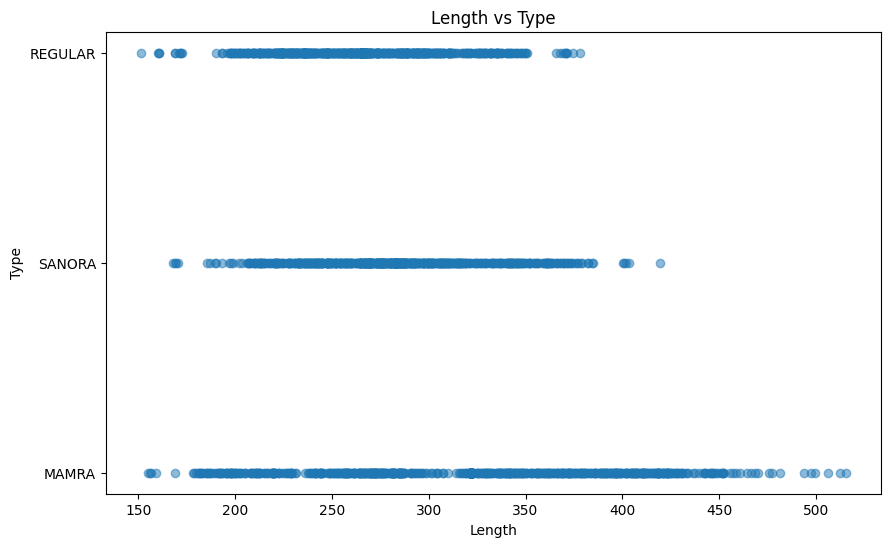

In [203]:
#Scatterplot of length vs type
plt.figure(figsize=(10, 6))
plt.scatter(almond['length'], almond['type'], alpha=0.5)

#Labels and title
plt.xlabel('Length')
plt.ylabel('Type')
plt.title('Length vs Type')

plt.show()

# Summary

## Accuracy Comparison

## Confusion Comparison

## Classification Reports